In [ ]:
import pandas as pd
matches = pd.read_csv("matches.csv")
matches = matches.dropna(subset=["winner", "venue"])

In [ ]:
top_venues = matches["venue"].value_counts().head(10).index.tolist()
top_matches = matches[matches["venue"].isin(top_venues)]

In [ ]:
top_matches["season"] = top_matches["season"].astype(str).str[:4].astype(int)
def get_era(season):
    return "Early IPL" if season < 2015 else "Modern IPL"
top_matches["era"] = top_matches["season"].apply(get_era)

In [42]:
print(top_matches["season"].head())
print(top_matches["season"].dtype)

0    2007
1    2007
2    2007
3    2007
4    2007
Name: season, dtype: int64
int64


In [43]:
def get_win_type(row):
    if row["winner"] == row["team1"]:
        return "Defend"
    elif row["winner"] == row["team2"]:
        return "Chase"
    else:
        return "Other"
top_matches["win_type"] = top_matches.apply(get_win_type, axis=1)

In [44]:
result = (
    top_matches.groupby(["venue", "era", "win_type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
result["total"] = result["Defend"] + result["Chase"]
result["defend_ratio"] = result["Defend"] / result["total"]
result["chase_ratio"] = result["Chase"] / result["total"]

/var/folders/b4/8w16gfhd69l6ldmc7_98ygrm0000gn/T/ipykernel_81019/4062187553.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=plot_df, x="venue", y="ratio", hue="type", ci=None)


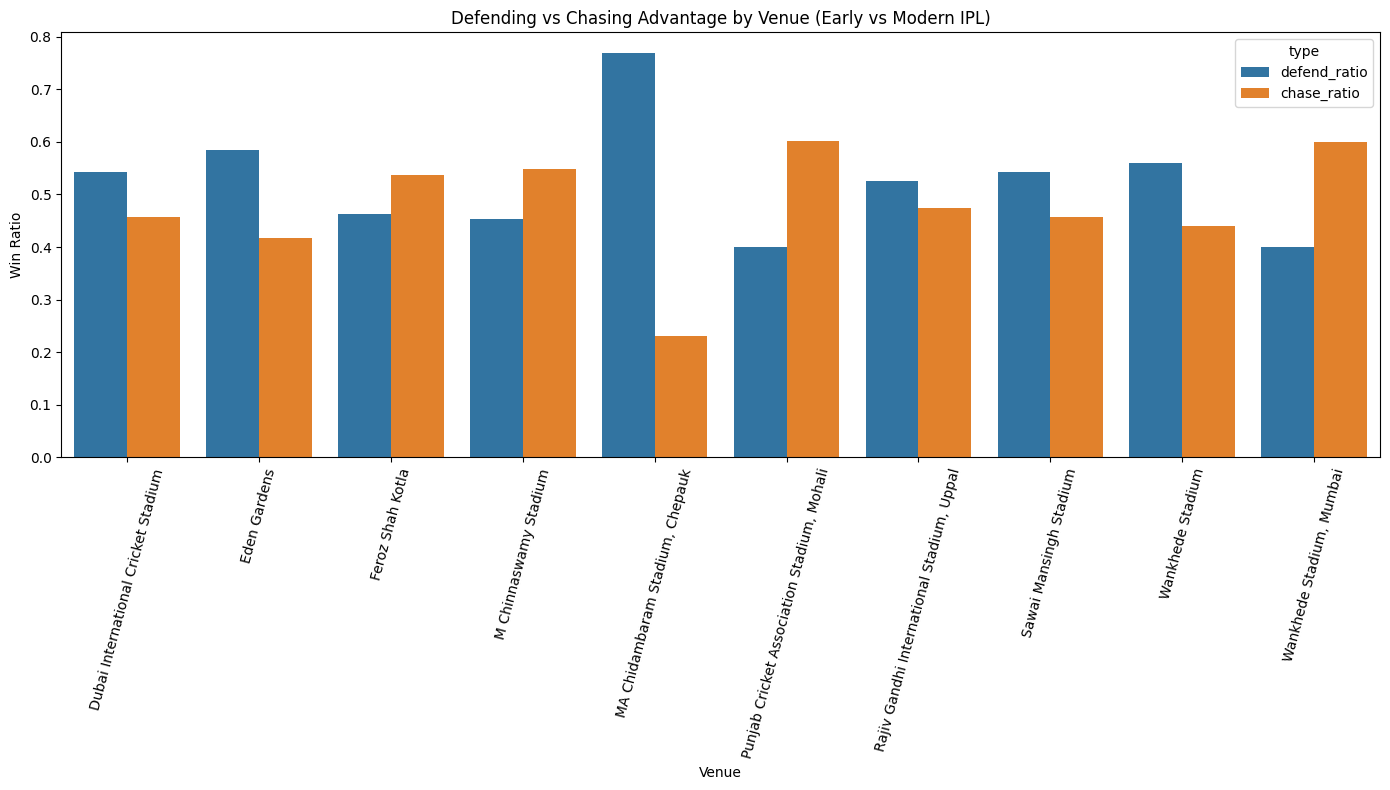

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
plot_df = result.melt(
    id_vars=["venue", "era"],
    value_vars=["defend_ratio", "chase_ratio"],
    var_name="type",
    value_name="ratio"
)
plt.figure(figsize=(14, 8))
sns.barplot(data=plot_df, x="venue", y="ratio", hue="type", ci=None)
plt.xticks(rotation=75)
plt.title("Defending vs Chasing Advantage by Venue (Early vs Modern IPL)")
plt.ylabel("Win Ratio")
plt.xlabel("Venue")
plt.tight_layout()
plt.show()